# Exploratory Data Analysis: Best Books Ever Dataset

This notebook performs an initial exploratory data analysis on the **Best Books Ever** dataset from Goodreads. The dataset contains 25 attributes with information about book characteristics, ratings, and metadata.

**Dataset Overview:**
- Source: Goodreads - Best Books Ever list
- Contains: Book titles, authors, ratings, genres, prices, and more

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Load the dataset
df = pd.read_csv('books_1.Best_Books_Ever.csv')
print(f"Dataset loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Dataset shape: 52478 rows × 25 columns


## 1. Load and Inspect the Dataset

Let's start by examining the structure of the dataset, including its shape, column names, data types, and previewing the first few rows.

In [5]:
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns\n")

df.head()


Shape: 52478 rows × 25 columns



,bookId,title,series,author,rating,description,language,isbn,genres,characters,...,firstPublishDate,awards,numRatings,ratingsByStars,likedPercent,setting,coverImg,bbeScore,bbeVotes,price
0,2767052-the-hunger-games,The Hunger Games,The Hunger Games #1,Suzanne Collins,4.33,WINNING MEANS FAME AND FORTUNE.LOSING MEANS CE...,English,9780439023481,"['Young Adult', 'Fiction', 'Dystopia', 'Fantas...","['Katniss Everdeen', 'Peeta Mellark', 'Cato (H...",...,NaN,['Locus Award Nominee for Best Young Adult Boo...,6376780,"['3444695', '1921313', '745221', '171994', '93...",96.0,"['District 12, Panem', 'Capitol, Panem', 'Pane...",https://i.gr-assets.com/images/S/compressed.ph...,2993816,30516,5.09
1,2.Harry_Potter_and_the_Order_of_the_Phoenix,Harry Potter and the Order of the Phoenix,Harry Potter #5,"J.K. Rowling, Mary GrandPré (Illustrator)",4.50,There is a door at the end of a silent corrido...,English,9780439358071,"['Fantasy', 'Young Adult', 'Fiction', 'Magic',...","['Sirius Black', 'Draco Malfoy', 'Ron Weasley'...",...,06/21/03,['Bram Stoker Award for Works for Young Reader...,2507623,"['1593642', '637516', '222366', '39573', '14526']",98.0,['Hogwarts School of Witchcraft and Wizardry (...,https://i.gr-assets.com/images/S/compressed.ph...,2632233,26923,7.38
2,2657.To_Kill_a_Mockingbird,To Kill a Mockingbird,To Kill a Mockingbird,Harper Lee,4.28,The unforgettable novel of a childhood in a sl...,English,9999999999999,"['Classics', 'Fiction', 'Historical Fiction', ...","['Scout Finch', 'Atticus Finch', 'Jem Finch', ...",...,07/11/60,"['Pulitzer Prize for Fiction (1961)', 'Audie A...",4501075,"['2363896', '1333153', '573280', '149952', '80...",95.0,"['Maycomb, Alabama (United States)']",https://i.gr-assets.com/images/S/compressed.ph...,2269402,23328,NaN
3,1885.Pride_and_Prejudice,Pride and Prejudice,NaN,"Jane Austen, Anna Quindlen (Introduction)",4.26,Alternate cover edition of ISBN 9780679783268S...,English,9999999999999,"['Classics', 'Fiction', 'Romance', 'Historical...","['Mr. Bennet', 'Mrs. Bennet', 'Jane Bennet', '...",...,01/28/13,[],2998241,"['1617567', '816659', '373311', '113934', '767...",94.0,"['United Kingdom', 'Derbyshire, England (Unite...",https://i.gr-assets.com/images/S/compressed.ph...,1983116,20452,NaN
4,41865.Twilight,Twilight,The Twilight Saga #1,Stephenie Meyer,3.60,About three things I was absolutely positive.\...,English,9780316015844,"['Young Adult', 'Fantasy', 'Romance', 'Vampire...","['Edward Cullen', 'Jacob Black', 'Laurent', 'R...",...,10/05/05,"['Georgia Peach Book Award (2007)', 'Buxtehude...",4964519,"['1751460', '1113682', '1008686', '542017', '5...",78.0,"['Forks, Washington (United States)', 'Phoenix...",https://i.gr-assets.com/images/S/compressed.ph...,1459448,14874,2.1


## 2. Data Quality Assessment

Let's analyze the completeness of each attribute and identify missing values and duplicates.

In [9]:
# Check for missing values and calculate completeness
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2),
    'Completeness_%': (100 - (df.isnull().sum() / len(df) * 100)).round(2)
})

missing_data = missing_data.sort_values('Missing_Percentage', ascending=False)

print("=" * 80)
print("MISSING VALUES")
print("=" * 80)
print(missing_data.to_string(index=False))

print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate rows based on bookId: {df.duplicated(subset=['bookId']).sum()}")

MISSING VALUES
          Column  Missing_Count  Missing_Percentage  Completeness_%
         edition          47523               90.56            9.44
          series          29008               55.28           44.72
firstPublishDate          21326               40.64           59.36
           price          14365               27.37           72.63
        language           3806                7.25           92.75
       publisher           3696                7.04           92.96
           pages           2347                4.47           95.53
      bookFormat           1473                2.81           97.19
     description           1338                2.55           97.45
     publishDate            880                1.68           98.32
    likedPercent            622                1.19           98.81
        coverImg            605                1.15           98.85
            isbn              0                0.00          100.00
           title              0  

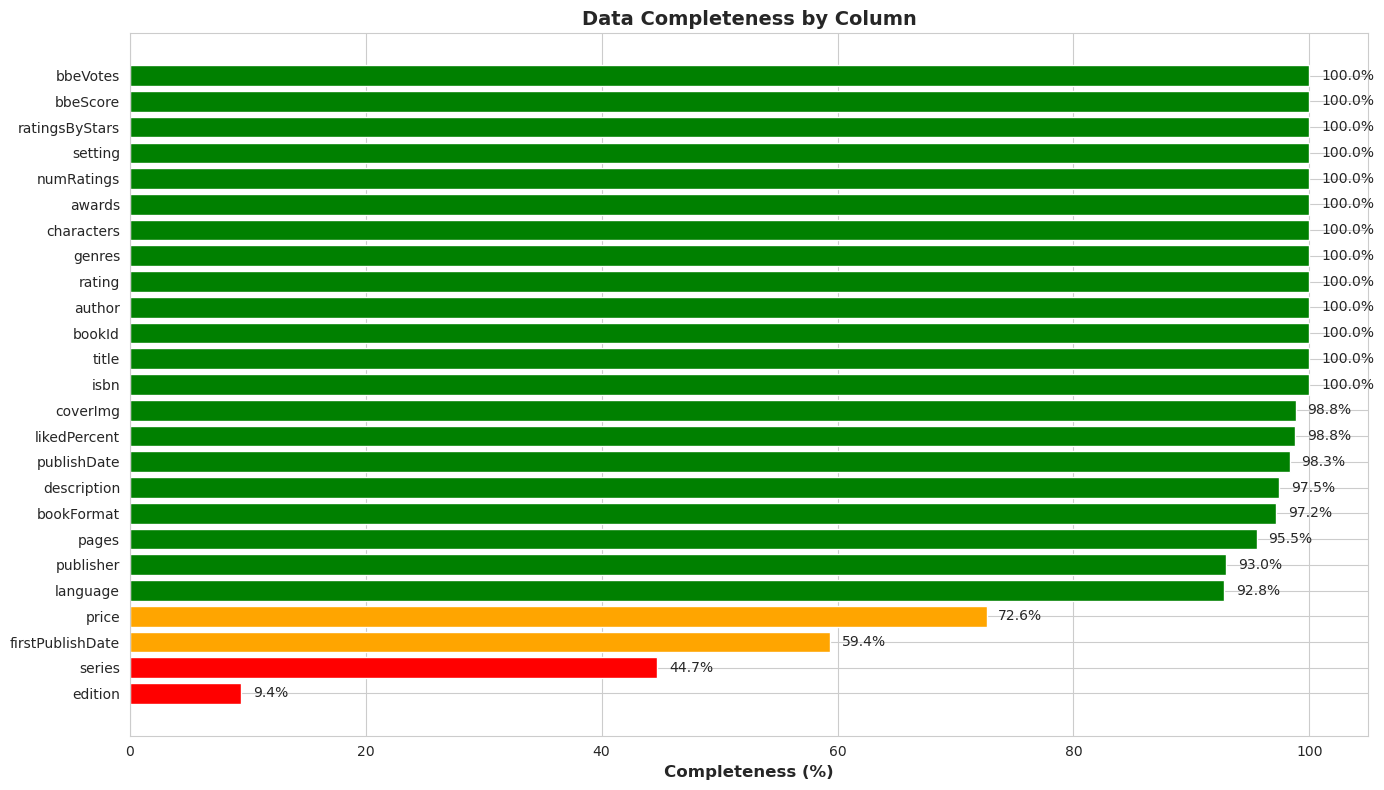

In [10]:
# Visualize data completeness
fig, ax = plt.subplots(figsize=(14, 8))

completeness_sorted = missing_data.sort_values('Completeness_%', ascending=True)
colors = ['red' if x < 50 else 'orange' if x < 80 else 'green' for x in completeness_sorted['Completeness_%']]

ax.barh(completeness_sorted['Column'], completeness_sorted['Completeness_%'], color=colors)
ax.set_xlabel('Completeness (%)', fontsize=12, fontweight='bold')
ax.set_title('Data Completeness by Column', fontsize=14, fontweight='bold')
ax.set_xlim(0, 105)

# Add value labels on bars
for i, v in enumerate(completeness_sorted['Completeness_%']):
    ax.text(v + 1, i, f'{v:.1f}%', va='center')

plt.tight_layout()
plt.show()

## 3. Univariate Analysis

We analyze here the distribution of the ratings, prices and like percentages.

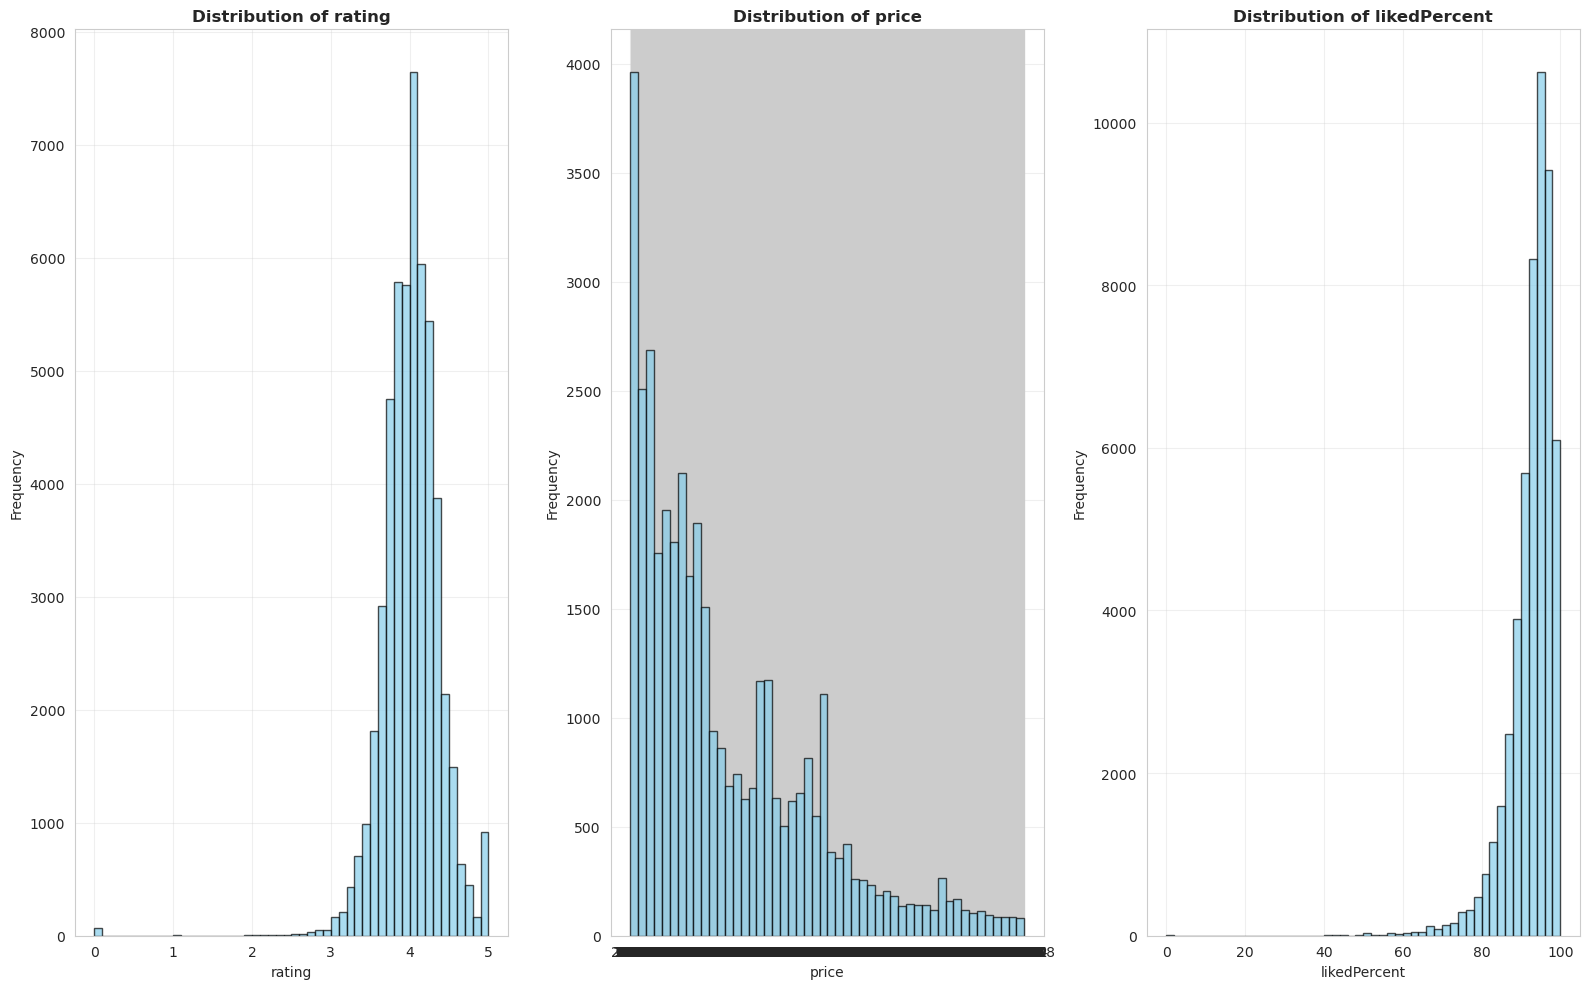

In [13]:
# Distributions of key numeric columns
key_numeric_cols = ['rating', 'price', 'likedPercent']
existing_cols = [col for col in key_numeric_cols if col in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(existing_cols):
    axes[idx].hist(df[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

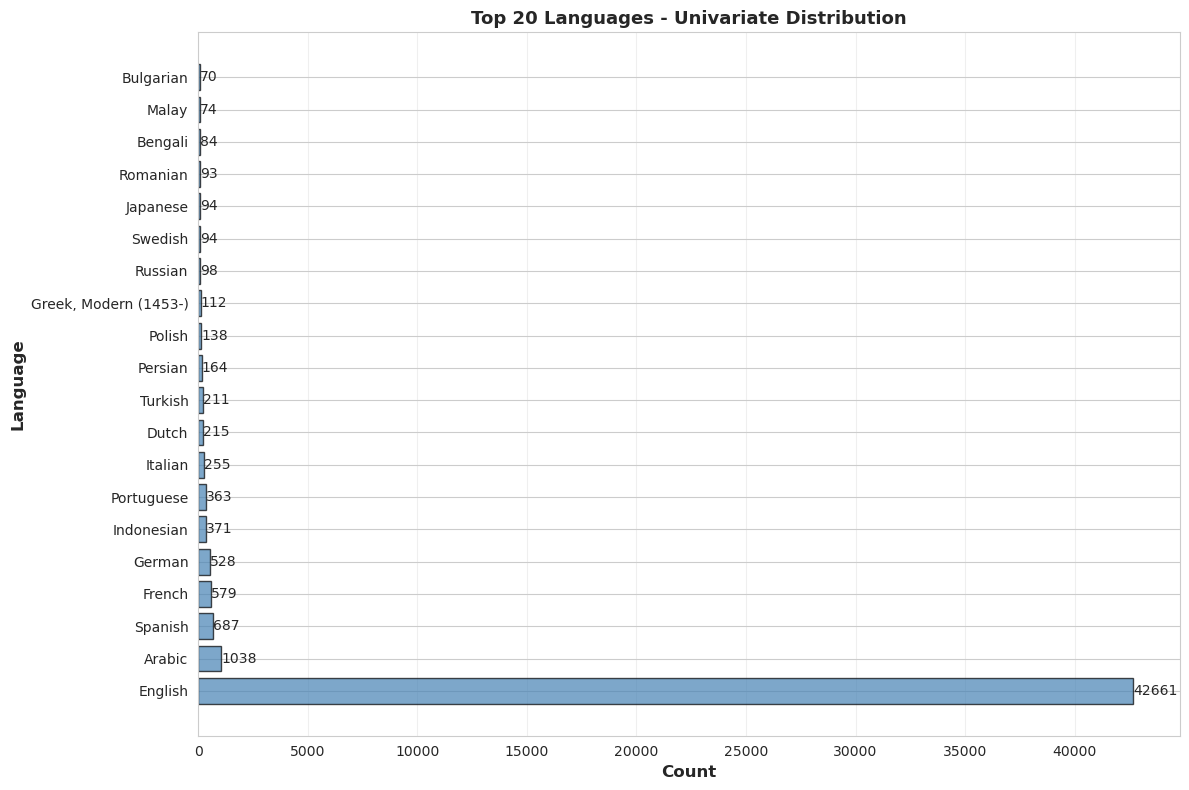

Total unique languages: 81


In [7]:
# Language distribution analysis
if 'language' in df.columns:
    fig, ax = plt.subplots(figsize=(12, 8))

    # Force native Python ints (some kernels convert numeric literals to custom Integer types)
    top_n = int("20")
    label_offset = int("5")

    language_clean = df['language'].dropna().astype(str).str.strip()
    language_clean = language_clean[language_clean != ""]

    lang_counts = language_clean.value_counts().iloc[:top_n]

    ax.barh(lang_counts.index, lang_counts.values, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel('Count', fontsize=12, fontweight='bold')
    ax.set_ylabel('Language', fontsize=12, fontweight='bold')
    ax.set_title('Top 20 Languages - Univariate Distribution', fontsize=13, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    # Add value labels on bars
    for i, v in enumerate(lang_counts.values):
        ax.text(int(v) + label_offset, i, str(int(v)), va='center')

    plt.tight_layout()
    plt.show()

    print(f"Total unique languages: {int(df['language'].nunique())}")

## 4. Rating and Popularity Insights

Investigate rating patterns, popularity metrics, and identify top-rated books.

In [16]:
# Analysis of ratings and popularity
print("=" * 80)
print("RATING AND POPULARITY ANALYSIS")
print("=" * 80)

if 'rating' in df.columns:
    print(f"\nRating Statistics:")
    print(f"  Mean Rating: {df['rating'].mean():.2f}")
    print(f"  Median Rating: {df['rating'].median():.2f}")
    print(f"  Std Dev: {df['rating'].std():.2f}")
    print(f"  Min Rating: {df['rating'].min():.2f}")
    print(f"  Max Rating: {df['rating'].max():.2f}")

if 'likedPercent' in df.columns:
    print(f"\nLiked Percent Statistics (ratings >= 2 stars):")
    print(f"  Mean: {df['likedPercent'].mean():.2f}%")
    print(f"  Median: {df['likedPercent'].median():.2f}%")
    print(f"  Std Dev: {df['likedPercent'].std():.2f}%")

if 'numRatings' in df.columns:
    print(f"\nNumber of Ratings Statistics:")
    print(f"  Mean: {df['numRatings'].mean():.0f}")
    print(f"  Median: {df['numRatings'].median():.0f}")
    print(f"  Max: {df['numRatings'].max():.0f}")

RATING AND POPULARITY ANALYSIS

Rating Statistics:
  Mean Rating: 4.02
  Median Rating: 4.03
  Std Dev: 0.37
  Min Rating: 0.00
  Max Rating: 5.00

Liked Percent Statistics (ratings >= 2 stars):
  Mean: 92.23%
  Median: 94.00%
  Std Dev: 5.99%

Number of Ratings Statistics:
  Mean: 17879
  Median: 2307
  Max: 7048471


## Summary

We can see this dataset is quite complete, as most column are mostly full. It contains useful data reflecting what people think about published books. While most books are in english, the data can still be used to gain valuable insights.